In [1]:
import numpy as np
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "stsb"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1379
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 5749
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1379
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'A plane is taking off.',
 'sentence2': 'An air plane is taking off.',
 'label': 5.0,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1']

'Some men are fighting.'

In [11]:
raw_train_dataset[5]['sentence2']

'Two men are fighting.'

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': Value('float32'),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1379
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 66]),
 'token_type_ids': torch.Size([32, 66]),
 'attention_mask': torch.Size([32, 66])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
num_labels = 1

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    problem_type="regression",
    # id2label=id2label,
    # label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(4.9161, grad_fn=<MseLossBackward0>) torch.Size([32, 1])


In [25]:
teacher_model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    problem_type="regression",
    # id2label=id2label,
    # label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
teacher_model.set_use_module_grafting(False)
teacher_model.set_use_scc_status(False)

In [27]:
outputs = teacher_model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(10.6868, grad_fn=<MseLossBackward0>) torch.Size([32, 1])


In [28]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
teacher_model.to(device)

device

device(type='cuda')

### Load Trained Weights

In [29]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [30]:
from train_eval_func import eval_loop

In [31]:
eval_loop(model, val_dataloader, task_name, device, regression=True)[0]

{'pearson': 0.900084701022039, 'spearmanr': 0.8962584593578651}

In [32]:
teacher_model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [33]:
eval_loop(model, val_dataloader, task_name, device, regression=True)[0]

{'pearson': 0.900084701022039, 'spearmanr': 0.8962584593578651}

# 5. FFN Drop

In [34]:
from layer_drop import layer_drop

In [35]:
from layer_merge_helper import reorder_merged_layer_heads, reorder_merged_layer_neurons

In [36]:
from structure_prune_helper import compute_importance_scores, register_importance_masks, remove_importance_masks

In [37]:
register_importance_masks(model, device, register_heads=True, register_ffn=True)

  Layer 0: Registered masks (12 heads, 3072 neurons)
  Layer 1: Registered masks (12 heads, 3072 neurons)
  Layer 2: Registered masks (12 heads, 3072 neurons)
  Layer 3: Registered masks (12 heads, 3072 neurons)
  Layer 4: Registered masks (12 heads, 3072 neurons)
  Layer 5: Registered masks (12 heads, 3072 neurons)
  Layer 6: Registered masks (12 heads, 3072 neurons)
  Layer 7: Registered masks (12 heads, 3072 neurons)
  Layer 8: Registered masks (12 heads, 3072 neurons)
  Layer 9: Registered masks (12 heads, 3072 neurons)
  Layer 10: Registered masks (12 heads, 3072 neurons)
  Layer 11: Registered masks (12 heads, 3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [38]:
from CKA import CKAEvaluator

cka_eval = CKAEvaluator(device)

In [39]:
reps_similarity, atts_similarity, sub_similarity = cka_eval.subLayer_interleaved_pairwise(
    model, 
    train_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=115
)
reps_stats = cka_eval.similarity_stats(reps_similarity)
atts_stats = cka_eval.similarity_stats(atts_similarity)
subs_stats = cka_eval.similarity_stats(sub_similarity)

print("  Reps Similarity Stats:")
print(f"    Average: {reps_stats['average']:.6f}")
print(f"    Highest: {reps_stats['max']:.6f}")
print(f"    Lowest:  {reps_stats['min']:.6f}")
print("")

print("  Atts Similarity Stats:")
print(f"    Average: {atts_stats['average']:.6f}")
print(f"    Highest: {atts_stats['max']:.6f}")
print(f"    Lowest:  {atts_stats['min']:.6f}")

print("  Sublayer Similarity Stats:")
print(f"    Average: {subs_stats['average']:.6f}")
print(f"    Highest: {subs_stats['max']:.6f}")
print(f"    Lowest:  {subs_stats['min']:.6f}")

CKA Sublayer Evaluation: 100%|██████████| 115/115 [00:29<00:00,  3.92it/s]

  Reps Similarity Stats:
    Average: 0.924553
    Highest: 0.993618
    Lowest:  0.547637

  Atts Similarity Stats:
    Average: 0.935507
    Highest: 0.992367
    Lowest:  0.783654
  Sublayer Similarity Stats:
    Average: 0.361834
    Highest: 0.657522
    Lowest:  0.185416


In [39]:
import matplotlib.pyplot as plt
import seaborn as sn

Text(50.722222222222214, 0.5, 'Layer')

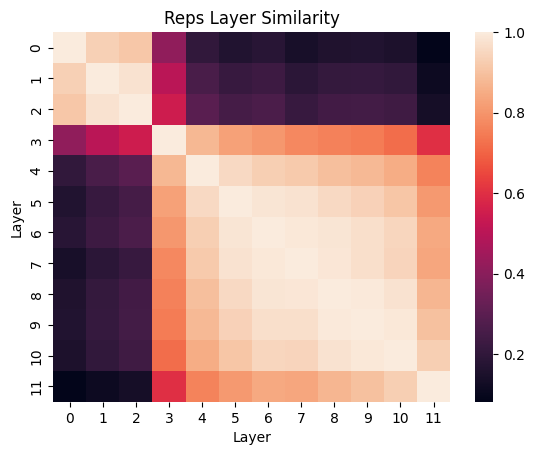

In [41]:
title = "Reps Layer Similarity"
plt.title(title)
sn.heatmap(data = reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

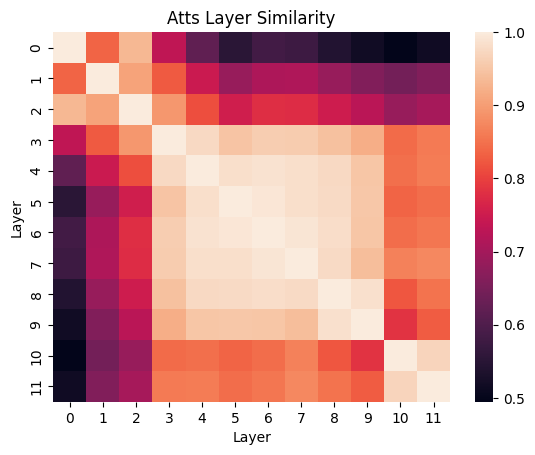

In [42]:
title = "Atts Layer Similarity"
plt.title(title)
sn.heatmap(data = atts_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

In [43]:
head_importance, neuron_importance = compute_importance_scores(model, train_dataloader, device, compute_heads=True, compute_ffn=True)

Computing importance (heads + FFN): 100%|██████████| 180/180 [00:15<00:00, 11.54it/s]


In [44]:
layer_scores = torch.tensor([
    h.mean().item()
    for h in head_importance
])

print(layer_scores.shape)
print(layer_scores)

torch.Size([12])
tensor([4.4982e-06, 3.9681e-06, 6.0533e-06, 7.2031e-06, 4.7330e-06, 7.1869e-06,
        3.3133e-06, 2.7440e-06, 4.5807e-06, 4.6696e-06, 3.5156e-06, 5.0097e-06])


In [45]:
normalized_scores = (
    (layer_scores - layer_scores.min())
    / (layer_scores.max() - layer_scores.min())
)
normalized_scores

tensor([0.3934, 0.2745, 0.7421, 1.0000, 0.4460, 0.9964, 0.1277, 0.0000, 0.4119,
        0.4318, 0.1730, 0.5081])

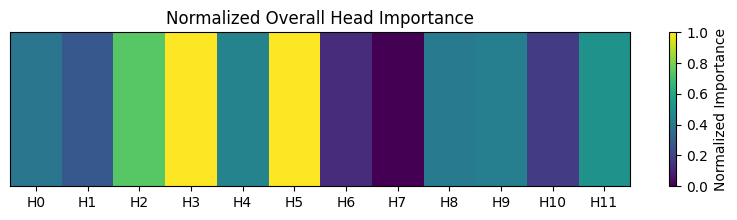

In [46]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall Head Importance")

plt.show()

In [47]:
neuron_layer_scores = torch.tensor([
    h.mean().item()
    for h in neuron_importance
])

print(neuron_layer_scores.shape)
print(neuron_layer_scores)

torch.Size([12])
tensor([1.5256e-07, 1.6192e-07, 1.8233e-07, 2.0381e-07, 2.1962e-07, 1.9473e-07,
        1.6965e-07, 1.7615e-07, 1.8696e-07, 1.8033e-07, 1.7263e-07, 1.4455e-07])


In [48]:
neuron_normalized_scores = (
    (neuron_layer_scores - neuron_layer_scores.min())
    / (neuron_layer_scores.max() - neuron_layer_scores.min())
)
neuron_normalized_scores

tensor([0.1067, 0.2314, 0.5033, 0.7895, 1.0000, 0.6684, 0.3344, 0.4210, 0.5650,
        0.4766, 0.3740, 0.0000])

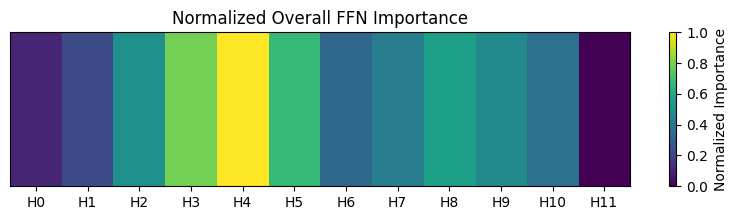

In [49]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    neuron_normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall FFN Importance")

plt.show()

In [40]:
def layer_score(importance):
    layer_scores = torch.tensor([
        h.mean().item()
        for h in importance
    ])

    normalized_scores = (
        (layer_scores - layer_scores.min())
        / (layer_scores.max() - layer_scores.min())
    )
    
    return normalized_scores

In [51]:
layer_score(neuron_importance)

tensor([0.1067, 0.2314, 0.5033, 0.7895, 1.0000, 0.6684, 0.3344, 0.4210, 0.5650,
        0.4766, 0.3740, 0.0000])

In [41]:
from layer_drop import ffn_drop

In [42]:
init_metric = eval_loop(model, val_dataloader, task_name, device, regression=True)[0]
init_metric

{'pearson': 0.900084701022039, 'spearmanr': 0.8962584593578651}

In [44]:
performance_track = ffn_drop(
    model, train_dataloader, val_dataloader, task_name, device, init_metric=init_metric, num_merges=9,
    cka_evaluator=cka_eval, teacher_model=teacher_model, drop_strategy="alt", recovery_lr=1e-5, regression=True,
    iterations=6
)

Target Metric for stsb: pearson
Original pearson score: 0.9001
Recovery threshold: 0.0090

 --> Iteration: 1
Number of Remaining MLPs: 11
  Post Operation Metrics:
    ★ pearson: 0.8809
      spearmanr: 0.8854
  Performance drop: 0.0192 (threshold: 0.0090)
  → Recovery training NEEDED
  → Training: 10 epochs, lr=1e-05


Training:   0%|          | 0/1800 [00:00<?, ?it/s]

Knowledge distillation used!


/home/abhinavl/work/Layer_Graft/layer-grafting-publication/ffn_drop_test/../train_eval_func.py:223: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss)
Training:  10%|█         | 180/1800 [00:22<03:10,  8.51it/s]

✓ Saved checkpoint (best loss: 0.4452)

<----------------- Epoch 1 ----------------->
Loss: 0.05, Training Metrics:
  pearson: 0.9774
  spearmanr: 0.9745
Validation Loss: 0.45, Validation Metrics:
  pearson: 0.8980
  spearmanr: 0.8946
Elapsed Time: 24.6447 sec


...

Training:  90%|████████▉ | 1619/1800 [04:16<00:18,  9.64it/s]

✓ Saved checkpoint (best loss: 0.7241)

<----------------- Epoch 9 ----------------->
Loss: 0.13, Training Metrics:
  pearson: 0.9354
  spearmanr: 0.9214
Validation Loss: 0.72, Validation Metrics:
  pearson: 0.8584
  spearmanr: 0.8565
Elapsed Time: 20.8642 sec


Training: 100%|██████████| 1800/1800 [04:57<00:00,  6.06it/s]

✓ Saved checkpoint (best loss: 0.7286)

<----------------- Epoch 10 ----------------->
Loss: 0.13, Training Metrics:
  pearson: 0.9385
  spearmanr: 0.9251
Validation Loss: 0.73, Validation Metrics:
  pearson: 0.8590
  spearmanr: 0.8572
Elapsed Time: 20.8452 sec

Total Training Time: 297.18 sec
Chosen Primary Metric: pearson
Best Metric Run: 0.8590

  → Loading best checkpoint...


  ✓ Loaded best checkpoint from epoch 10
    Best val loss: 0.7286
    Best val metrics: {'pearson': 0.8590039758483764, 'spearmanr': 0.8572202509572195}
  ✓ Cleaned up temporary checkpoint
  • 6 layers (not in target list, skipping save)



In [45]:
torch.save(performance_track, f'./weights/alt/performance_track_{task_name}.pt')

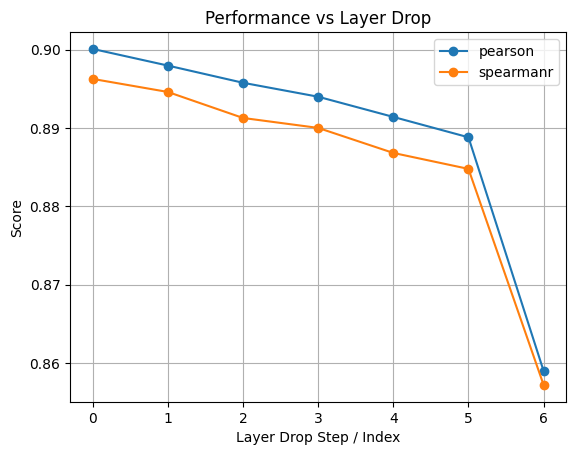

In [46]:
performance_track = performance_track['performance_track']

# get all metric names dynamically
metrics = performance_track[0].keys()

x = list(range(len(performance_track)))  # e.g., layer index or drop step

plt.figure()

for metric in metrics:
    y = [entry.get(metric, None) for entry in performance_track]
    plt.plot(x, y, marker='o', label=metric)

plt.xlabel("Layer Drop Step / Index")
plt.ylabel("Score")
plt.title("Performance vs Layer Drop")
plt.legend()
plt.grid()

plt.show()

In [47]:
reps_similarity, atts_similarity, sub_similarity = cka_eval.subLayer_interleaved_pairwise(
    model, 
    train_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=115
)
reps_stats = cka_eval.similarity_stats(reps_similarity)
atts_stats = cka_eval.similarity_stats(atts_similarity)
subs_stats = cka_eval.similarity_stats(sub_similarity)

print("  Reps Similarity Stats:")
print(f"    Average: {reps_stats['average']:.6f}")
print(f"    Highest: {reps_stats['max']:.6f}")
print(f"    Lowest:  {reps_stats['min']:.6f}")
print("")

print("  Atts Similarity Stats:")
print(f"    Average: {atts_stats['average']:.6f}")
print(f"    Highest: {atts_stats['max']:.6f}")
print(f"    Lowest:  {atts_stats['min']:.6f}")

print("  Sublayer Similarity Stats:")
print(f"    Average: {subs_stats['average']:.6f}")
print(f"    Highest: {subs_stats['max']:.6f}")
print(f"    Lowest:  {subs_stats['min']:.6f}")

CKA Sublayer Evaluation: 100%|██████████| 115/115 [00:28<00:00,  4.02it/s]

  Reps Similarity Stats:
    Average: 0.897196
    Highest: 0.972404
    Lowest:  0.627673

  Atts Similarity Stats:
    Average: 0.880988
    Highest: 0.959487
    Lowest:  0.762137
  Sublayer Similarity Stats:
    Average: 0.470001
    Highest: 0.644044
    Lowest:  0.311332


Text(50.722222222222214, 0.5, 'Layer')

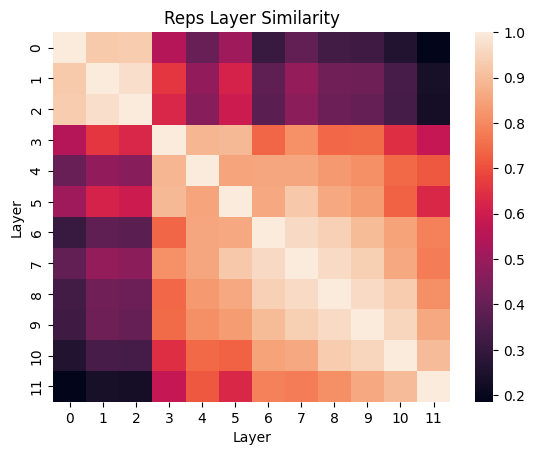

In [48]:
title = "Reps Layer Similarity"
plt.title(title)
sn.heatmap(data = reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

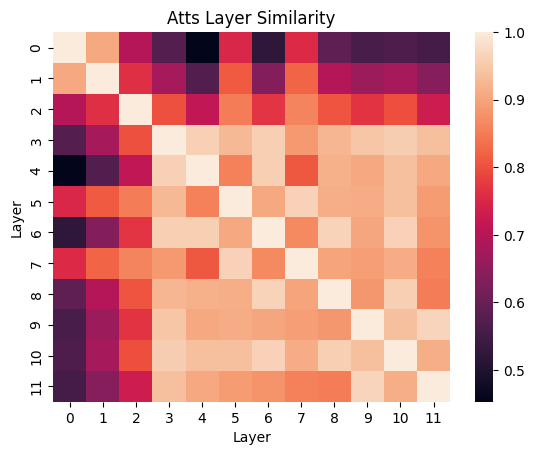

In [49]:
title = "Atts Layer Similarity"
plt.title(title)
sn.heatmap(data = atts_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

In [50]:
head_importance, neuron_importance = compute_importance_scores(model, train_dataloader, device, compute_heads=True, compute_ffn=True)

Computing importance (heads + FFN): 100%|██████████| 180/180 [00:11<00:00, 15.79it/s]


In [51]:
layer_scores = torch.tensor([
    h.mean().item()
    for h in head_importance
])

print(layer_scores.shape)
print(layer_scores)

torch.Size([12])
tensor([3.5095e-05, 5.3616e-05, 3.4363e-05, 2.9073e-05, 2.3258e-05, 4.4083e-05,
        2.1242e-05, 2.0629e-05, 1.6878e-05, 5.8717e-05, 2.7262e-05, 2.4521e-05])


In [52]:
normalized_scores = (
    (layer_scores - layer_scores.min())
    / (layer_scores.max() - layer_scores.min())
)
normalized_scores

tensor([0.4354, 0.8781, 0.4179, 0.2915, 0.1525, 0.6502, 0.1043, 0.0897, 0.0000,
        1.0000, 0.2482, 0.1827])

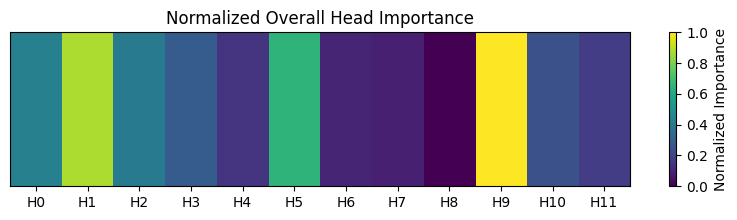

In [53]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall Head Importance")

plt.show()

In [54]:
neuron_layer_scores = torch.tensor([
    h.mean().item() if h is not None else 0.0
    for h in neuron_importance
])

print(neuron_layer_scores.shape)
print(neuron_layer_scores)

torch.Size([12])
tensor([7.8951e-07, 0.0000e+00, 8.4719e-07, 0.0000e+00, 1.1578e-06, 0.0000e+00,
        9.2154e-07, 0.0000e+00, 8.9973e-07, 0.0000e+00, 6.1927e-07, 0.0000e+00])


In [55]:
neuron_normalized_scores = (
    (neuron_layer_scores - neuron_layer_scores.min())
    / (neuron_layer_scores.max() - neuron_layer_scores.min())
)
neuron_normalized_scores

tensor([0.6819, 0.0000, 0.7317, 0.0000, 1.0000, 0.0000, 0.7959, 0.0000, 0.7771,
        0.0000, 0.5349, 0.0000])

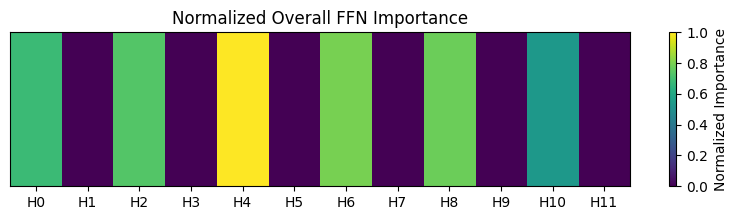

In [56]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    neuron_normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall FFN Importance")

plt.show()

In [57]:
from pathlib import Path

def compute_size(model):
    state_dict = model.state_dict()
    tmp_path = Path("model.pt")
    torch.save(state_dict, tmp_path)
    # Calculate size in megabytes
    size_mb = Path(tmp_path).stat().st_size / (1024 * 1024)
    # Delete temporary file
    tmp_path.unlink()
    print(f"Model size (MB) - {size_mb:.2f}")
    # return size_mb

In [58]:
compute_size(teacher_model)

Model size (MB) - 417.71


In [59]:
compute_size(model)

Model size (MB) - 309.69


In [60]:
import numpy as np

In [61]:
from time import perf_counter

def time_pipeline(model, dataloader, device):
    latencies = []
    
    # Warmup
    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        model(**batch)
        break
        
    # Timed run
    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        start_time = perf_counter()
        model(**batch)
        latency = perf_counter() - start_time
        latencies.append(latency)
    # Compute run statistics
    time_avg_ms = 1000 * np.mean(latencies)
    time_std_ms = 1000 * np.std(latencies)
    print(f"Average latency (ms) - {time_avg_ms:.2f} +\- {time_std_ms:.2f}")
    # return {"time_avg_ms": time_avg_ms, "time_std_ms": time_std_ms}

In [62]:
time_pipeline(teacher_model, val_dataloader, device)

Average latency (ms) - 3.06 +\- 0.10


In [63]:
time_pipeline(model, val_dataloader, device)

Average latency (ms) - 3.49 +\- 1.18
